# bayesian fits

This notebook contains the code to perform the Bayesian fits shown in the manuscript 

Catalán et al. 2026 ...

In [116]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pylab
import numpy as np
from scipy.integrate import solve_ivp
import itertools
import subprocess
import pandas as pd
import os
from scipy.optimize import curve_fit
import pymc as pm
import arviz as az
matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"
RANDOM_SEED = 89271458
rng = np.random.default_rng(RANDOM_SEED)

def mexCDvsDC(x,a,b,c):
    return a*(1+(x/b)**2)/(c+(x/b)**2)
    
def MICCIPvsDC(x,A,B,C):
    #return A+(1+(x/B)**2)/(C+(x/B)**2)
    return A*(1+C*(x/B)**2)/(1+(x/B)**2)
    
def MICTOBvsDC(x,A,B,C):
    #return A+1/(C+(x/B)**2)
    return A*(1+C*(x/B)**2)/(1+(x/B)**2)

# FIGURE 1
## MexCD is over-expressed by DC

In the main text, we derive the following relation between the concentration of dequalinum chloride (DC) and the expression of MexCD:
$$[\text{MexCD}]=a\frac{1+\left(\frac{[\text{DC}]}b\right)^2}{c+\left(\frac{[\text{DC}]}b\right)^2}$$
In the following cell, we obtain the posterior distribution of the parameters given our laboratory data (Laborda et al. 2019), where we have measured $[\text{MexCD}]$ using luminiscence.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, c, sigma]
/home/pcatalan/anaconda3/envs/pymc_env/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 15 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.785,0.034,1.723,1.849,0.000,0.000,30889.0,25791.0,1.0
b,0.857,0.199,0.531,1.217,0.001,0.002,27551.0,22808.0,1.0
c,1.656,0.093,1.480,1.826,0.001,0.001,26902.0,23775.0,1.0
sigma,0.109,0.020,0.076,0.147,0.000,0.000,25611.0,25039.0,1.0


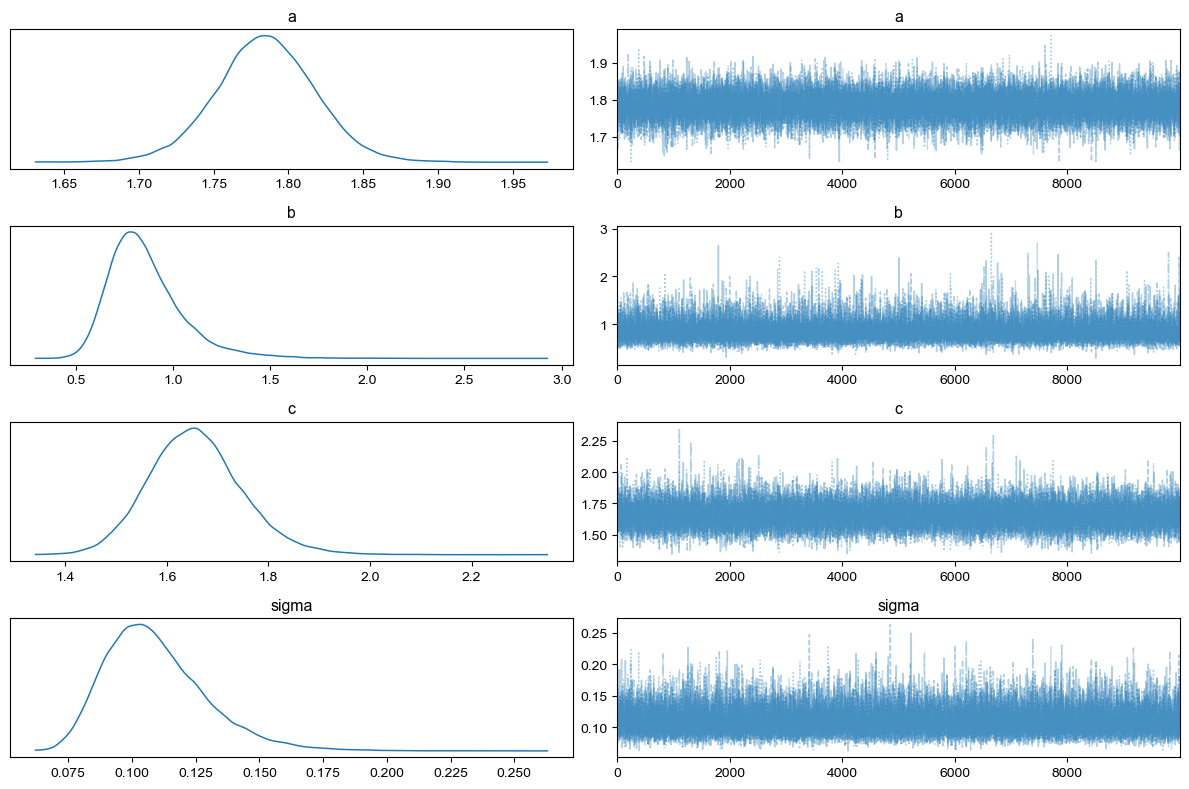

In [80]:
DF=pd.read_csv('data/DC_mexCD.csv')
DC=np.array(DF['DC'])
y=np.array(DF['mexCD'])


# Define generative model
with pm.Model() as generative_model:
   x = pm.Data("x", DC)
   # Model parameters
   a=pm.HalfNormal('a')
   b=pm.HalfNormal('b')
   c=pm.HalfNormal('c')
   sigma=pm.HalfNormal('sigma')

   # Define likelihood
   likelihood = pm.Normal("M", mu=mexCDvsDC(x,a,b,c), sigma=sigma, observed=y)
   idata = pm.sample(draws=10000)

az.plot_trace(idata, combined=True)
plt.tight_layout()
az.summary(idata)

Having obtained a good fit (values of r-hat close to 1 are a good indicator of algorihtm convergence) we set out now to plot the predictive posterior distribution, i.e., for each value of $[\text{DC}]$, what is the probability distribution of values of $[\text{MexCD}]$ so that we get a sense of uncertainty of our fit. 

The object idata.posterior holds several (a,b,c) values. For each of these, and for a range of values of $[\text{DC}]$, we will predict the value of $[\text{MexCD}]$.

In order to better plot this, we use a 2D histogram that visuallly shows where the probability is highest. We also plot the average of the $y$ prediction for each $x$, yielding an orange line that coincides exactly with the maximum likelihood line.

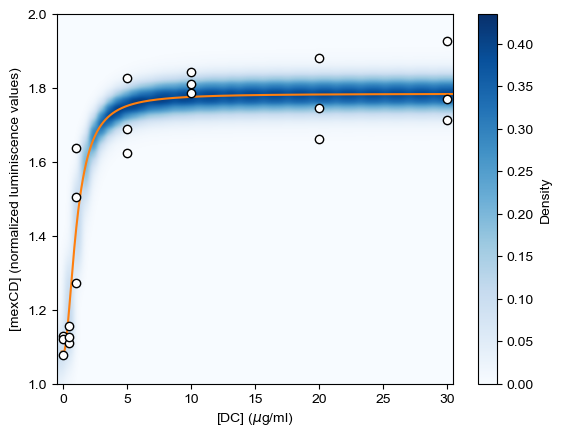

In [81]:
post = idata.posterior
ar=post['a']
br=post['b']
cr=post['c']
YP=[]
YPmean=[]
xp=np.linspace(-0.1,30.5,1000)
for x in xp:#for all values in the range, obtain the corresponding y value
    yp = np.asarray(mexCDvsDC(x, ar, br, cr)).squeeze()
    yp_combined = yp.flatten()
    YPmean.append(yp.mean())
    YP.append(yp_combined)
# Flatten the data:
# Here we assume every element in YP is an array with the same number of samples
n_samples = YP[0].shape[0]
x_repeated = np.repeat(xp, n_samples)  # Repeat each x value n_samples times
y_flattened = np.concatenate(YP)         # Flatten the list of y arrays into one array

# Plot a 2D histogram
xedges=np.linspace(-0.5,30.5,50)
yedges=np.linspace(1,2,50)
heatmap, xedges, yedges = np.histogram2d(x_repeated, y_flattened, density=True, bins=[xedges,yedges])
plt.imshow(heatmap.T, 
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           origin='lower', aspect='auto',
           interpolation='gaussian', 
           cmap='Blues')
plt.plot(xp,YPmean,color='C1')
plt.ylabel('[mexCD] (normalized luminiscence values)')
plt.xlabel('[DC] ($\\mu$g/ml)')
plt.colorbar(label='Density')
plt.plot(DC,y,'ow', markeredgecolor='k')
plt.ylim([1,2])

plt.savefig('figures/fig1B.png', bbox_inches='tight', dpi=300)

# FIGURE 3
## Over-expression of MexCD results in CS towards aminoglycosides

In the main text, we derived the following expressions refrerring concentration of DC with MIC towards CIP and TOB:
$$\text{MIC}_{\text{CIP}}=A_{\text{CIP}}\frac{1+C_{\text{CIP}}\left(\frac{[\text{DC}]}{B_{\text{CIP}}}\right)^2}{1+\left(\frac{[\text{DC}]}{B_{\text{CIP}}}\right)^2}$$
$$\text{MIC}_{\text{TOB}}=A_{\text{TOB}}\frac{1+C_{\text{TOB}}\left(\frac{[\text{DC}]}{B_{\text{TOB}}}\right)^2}{1+\left(\frac{[\text{DC}]}{B_{\text{TOB}}}\right)^2}$$
In the following cells, we obtain the posterior distribution of the parameters given our checkerboard experiments where we measured the MIC for different concentrations of DC. We took the MIC to be the average between the minimal concentration of antibiotic that inhibited growth and the maximal concentration that allowed growth, understanding that the actual MIC could be anywhere between the two concentrations. So, for instance, if a concentration 0.125 μg/ml allowed growth but the next concentration measured 0.25 μg/ml didn’t, we take the MIC to be 0.1875 μg/ml.

The code below summarizes the output of Bayesian estimation, plotting the marginal posterior distributions for each parameter as well as mean, standard deviation and so on.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, B, C, sigma]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 19 seconds.
There were 2762 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A,0.074,0.019,0.044,0.111,0.000,0.000,2257.0,3614.0,1.0
B,0.390,0.369,0.001,1.067,0.006,0.008,4303.0,6668.0,1.0
C,2.103,0.577,0.962,3.176,0.012,0.009,2438.0,3994.0,1.0
sigma,0.023,0.014,0.007,0.046,0.000,0.000,1351.0,982.0,1.0


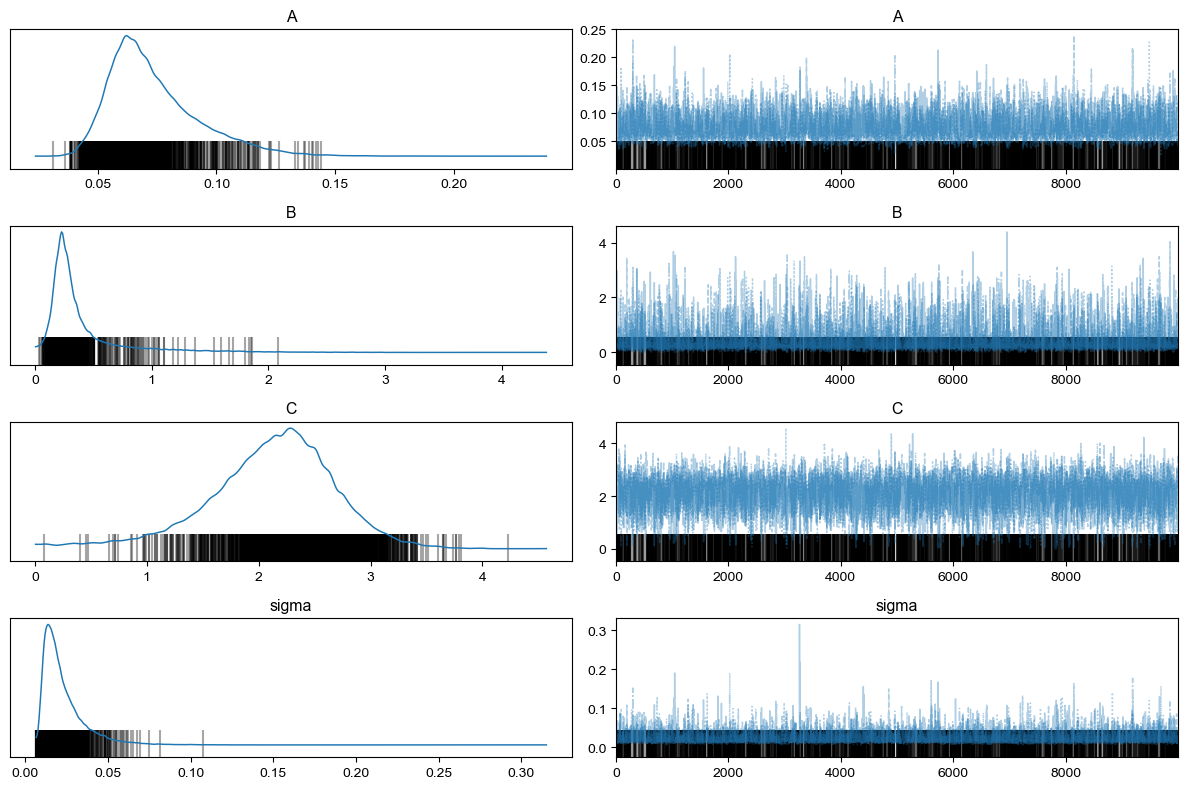

In [117]:
DF=pd.read_csv('data/mic_data.csv')
DCnew=DF['DC']
MICcip=DF['CIPavg']
MICtob=DF['TOBavg']

# Define generative model for CIP
with pm.Model() as modelCIP:
   x = pm.Data("x", DCnew)
   # Model parameters
   A=pm.HalfNormal('A')
   B=pm.HalfNormal('B')
   C=pm.HalfNormal('C')
   sigma=pm.HalfNormal('sigma')

   # Define likelihood
   likelihood = pm.Normal("MIC", mu=MICCIPvsDC(x,A,B,C), sigma=sigma, observed=MICcip)
   idataCIP = pm.sample(draws=10000)
az.plot_trace(idataCIP, combined=True)
plt.tight_layout()
az.summary(idataCIP)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A, B, C, sigma]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 18 seconds.
There were 435 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A,0.215,0.039,0.133,0.280,0.000,0.000,8434.0,10534.0,1.0
B,0.291,0.332,0.001,0.893,0.004,0.006,7906.0,12245.0,1.0
C,0.428,0.182,0.056,0.714,0.002,0.003,11334.0,6730.0,1.0
sigma,0.037,0.018,0.014,0.069,0.000,0.000,3897.0,3261.0,1.0


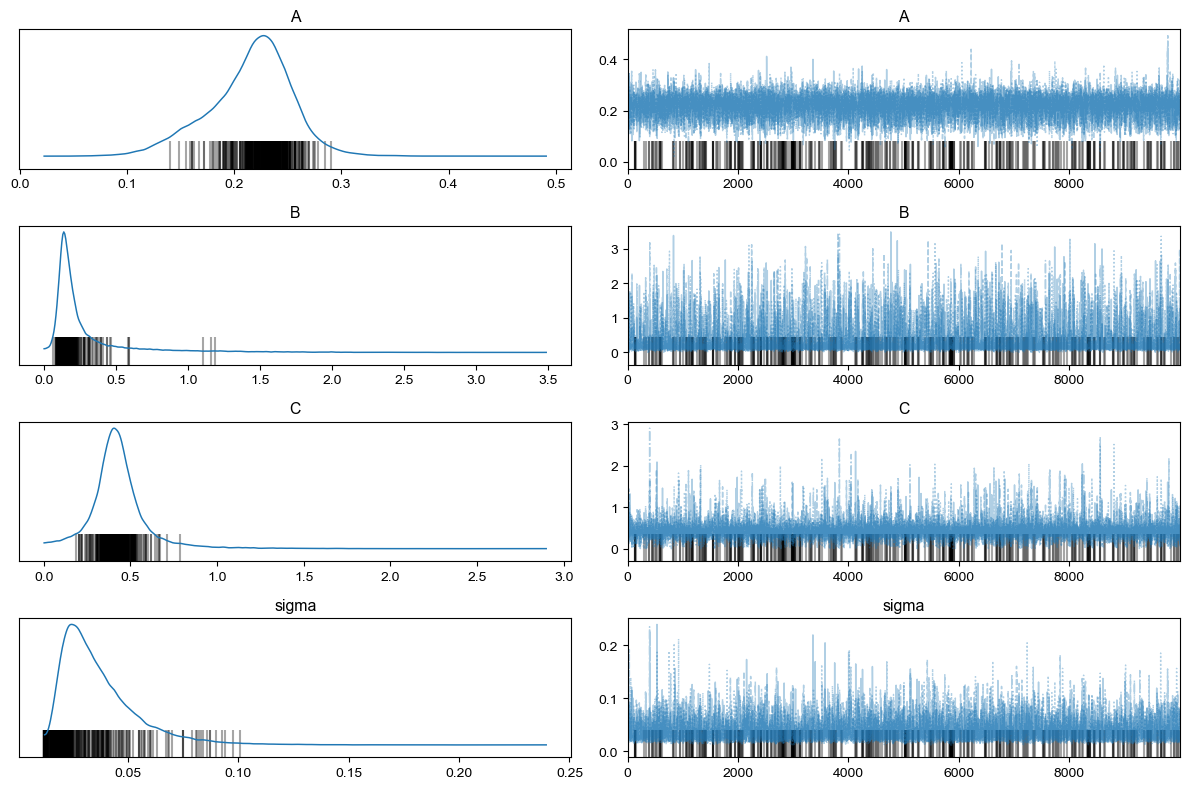

In [119]:
# Define generative model for TOB
with pm.Model() as modelTOB:
   x = pm.Data("x", DCnew)
   # Model parameters
   A=pm.HalfNormal('A')
   B=pm.HalfNormal('B')
   C=pm.HalfNormal('C')
   sigma=pm.HalfNormal('sigma')

   # Define likelihood
   likelihood = pm.Normal("MIC", mu=MICTOBvsDC(x,A,B,C), sigma=sigma, observed=MICtob)
   idataTOB = pm.sample(draws=10000)  
az.plot_trace(idataTOB, combined=True)
plt.tight_layout()
az.summary(idataTOB)

Having obtained a good fit (values of r-hat close to 1 are a good indicator of algorihtm convergence) we set out now to plot the predictive posterior distribution, i.e., for each value of $[\text{DC}]$, what is the probability distribution of values of $\text{MIC}_{\text{CIP}}$ and $\text{MIC}_{\text{TOB}}$, as we did before for Figure 1B.

The object idata.posterior holds several (A,B,C) values. For each of these, and for a range of values of $[\text{DC}]$, we will predict the value of $\text{MIC}_{\text{CIP}}$ and $\text{MIC}_{\text{TOB}}$.

In order to better plot this, we use a 2D histogram that visuallly shows where the probability is highest. We also plot the average of the $y$ prediction for each $x$, yielding an orange line that coincides exactly with the maximum likelihood line.

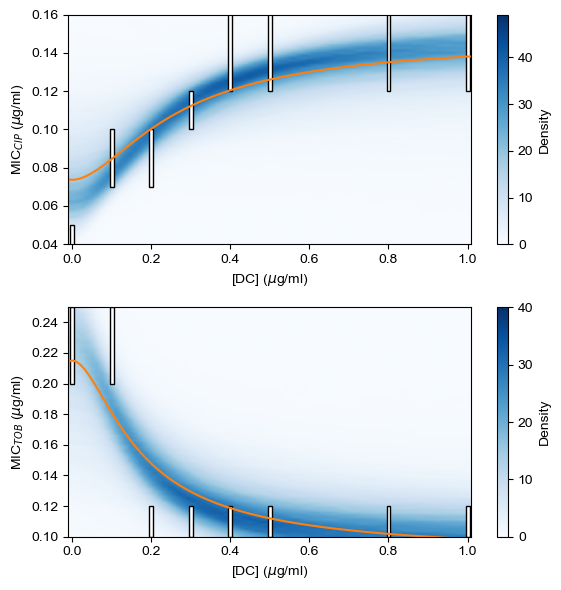

In [122]:
CIPm=DF['CIPm']
CIPM=DF['CIPM']
TOBm=DF['TOBm']
TOBM=DF['TOBM']

fig=plt.figure(figsize=(6,6))
ax=fig.add_subplot(2,1,1)
post = idataCIP.posterior
Ar=post['A']
Br=post['B']
Cr=post['C']
YP=[]
YPmean=[]
xp=np.linspace(-0.1,1.1,200)
for x in xp:
    yp = np.asarray(MICCIPvsDC(x, Ar, Br, Cr)).squeeze()
    yp_combined = yp.flatten()
    YPmean.append(yp.mean())
    YP.append(yp_combined)
# Flatten the data:
# Here we assume every element in YP is an array with the same number of samples
n_samples = YP[0].shape[0]
x_repeated = np.repeat(xp, n_samples)  # Repeat each x value n_samples times
y_flattened = np.concatenate(YP)         # Flatten the list of y arrays into one array

# 2D HISTOGRAM
xedges=np.linspace(-0.1,1.1,100)
yedges=np.linspace(0.03,0.16,100)
heatmap, xedges, yedges = np.histogram2d(x_repeated, y_flattened, density=True, bins=[xedges,yedges])
plt.imshow(heatmap.T, 
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           origin='lower', aspect='auto',
           interpolation='gaussian', 
           cmap='Blues')
plt.plot(xp,YPmean,color='C1')
plt.xlabel('[DC] ($\\mu$g/ml)')
ax.set_ylabel('MIC$_{CIP}$ ($\\mu$g/ml)')
plt.colorbar(label='Density')
ax.bar(DC,CIPM-CIPm,bottom=CIPm,width=0.01,edgecolor='k', facecolor='w')
plt.xlim([-0.01,1.01])
plt.ylim([0.04,0.16])

##################
# FIG 3B: TOB 
##################
ax=fig.add_subplot(2,1,2)
post = idataTOB.posterior
Ar=post['A']
Br=post['B']
Cr=post['C']
YP=[]
YPmean=[]
xp=np.linspace(-0.1,1.1,200)
for x in xp:
    yp = np.asarray(MICTOBvsDC(x, Ar, Br, Cr)).squeeze()
    yp_combined = yp.flatten()
    YPmean.append(yp.mean())
    YP.append(yp_combined)
# Flatten the data:
# Here we assume every element in YP is an array with the same number of samples
n_samples = YP[0].shape[0]
x_repeated = np.repeat(xp, n_samples)  # Repeat each x value n_samples times
y_flattened = np.concatenate(YP)         # Flatten the list of y arrays into one array

# 2D HISTOGRAM
xedges=np.linspace(-0.1,1.1,100)
yedges=np.linspace(0.1,0.25,100)
heatmap, xedges, yedges = np.histogram2d(x_repeated, y_flattened, density=True, bins=[xedges,yedges])
plt.imshow(heatmap.T, 
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           origin='lower', aspect='auto',
           interpolation='gaussian', 
           cmap='Blues')
plt.plot(xp,YPmean,color='C1')
plt.xlabel('[DC] ($\\mu$g/ml)')
ax.set_ylabel('MIC$_{TOB}$ ($\\mu$g/ml)')
plt.colorbar(label='Density')
ax.bar(DC,TOBM-TOBm,bottom=TOBm,width=0.01,edgecolor='k', facecolor='w')
plt.xlim([-0.01,1.01])
plt.ylim([0.1,0.25])

fig.tight_layout()
fig.savefig('figures/fig3.png', bbox_inches='tight', dpi=300)